#Carga y exploración de los datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")

# Cargar el archivo
df = pd.read_csv("/content/drive/MyDrive/RutaProgramacion/Proyectos/Lemonade.txt", sep=",")  # cambia el separador si es necesario

# Vista general
df

,Date,Día,Temperature,Rainfall,Flyers,Price,Sales
0,01/01/2017,Sunday,27.0,2.00,15,0.3,10
1,02/01/2017,Monday,28.9,1.33,15,0.3,13
2,03/01/2017,Tuesday,34.5,1.33,27,0.3,15
3,04/01/2017,Wednesday,44.1,1.05,28,0.3,17
4,05/01/2017,Thursday,42.4,1.00,33,0.3,18
...,...,...,...,...,...,...,...
360,27/12/2017,Wednesday,42.7,1.00,33,0.3,19
361,28/12/2017,"Thu""#$%&rsday",37.8,1.25,32,0.3,16
362,29/12/2017,Friday,39.5,1.25,17,0.3,15
363,30/12/2017,Saturday,30.9,1.43,22,0.3,13


In [ ]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         365 non-null    object 
 1   Día          365 non-null    object 
 2   Temperature  365 non-null    float64
 3   Rainfall     365 non-null    float64
 4   Flyers       365 non-null    int64  
 5   Price        365 non-null    float64
 6   Sales        365 non-null    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 20.1+ KB


In [ ]:
#Lo anterior nos indica que todas las celdas del DataSet estan ocupadas; es decir, no hay Nulls

In [ ]:
# Estadísticos básicos
df.describe()

,Temperature,Rainfall,Flyers,Price,Sales
count,365.000000,365.000000,365.000000,365.000000,365.000000
mean,59.605753,0.826603,40.284932,0.333973,25.323288
std,17.992816,0.273171,13.178651,0.075206,6.893589
min,1.100000,0.470000,9.000000,0.300000,7.000000
25%,48.700000,0.650000,31.000000,0.300000,20.000000
50%,60.800000,0.740000,39.000000,0.300000,25.000000
75%,71.300000,0.910000,49.000000,0.300000,30.000000
max,102.900000,2.500000,80.000000,0.500000,43.000000


In [ ]:
#describe() nos permite identificar rápidamente medias, medianas aproximadas, dispersión y posibles valores extremos.
#Si la media es muy diferente a la mediana → posible asimetría.

#Convertir la col temperatura en Celcius

In [ ]:
df['Temperature']=(df['Temperature']-32)*5/9

In [ ]:
df.describe()

,Temperature,Rainfall,Flyers,Price,Sales
count,365.000000,365.000000,365.000000,365.000000,365.000000
mean,15.336530,0.826603,40.284932,0.333973,25.323288
std,9.996009,0.273171,13.178651,0.075206,6.893589
min,-17.166667,0.470000,9.000000,0.300000,7.000000
25%,9.277778,0.650000,31.000000,0.300000,20.000000
50%,16.000000,0.740000,39.000000,0.300000,25.000000
75%,21.833333,0.910000,49.000000,0.300000,30.000000
max,39.388889,2.500000,80.000000,0.500000,43.000000


In [ ]:
df

,Date,Día,Temperature,Rainfall,Flyers,Price,Sales
0,01/01/2017,Sunday,-2.777778,2.00,15,0.3,10
1,02/01/2017,Monday,-1.722222,1.33,15,0.3,13
2,03/01/2017,Tuesday,1.388889,1.33,27,0.3,15
3,04/01/2017,Wednesday,6.722222,1.05,28,0.3,17
4,05/01/2017,Thursday,5.777778,1.00,33,0.3,18
...,...,...,...,...,...,...,...
360,27/12/2017,Wednesday,5.944444,1.00,33,0.3,19
361,28/12/2017,"Thu""#$%&rsday",3.222222,1.25,32,0.3,16
362,29/12/2017,Friday,4.166667,1.25,17,0.3,15
363,30/12/2017,Saturday,-0.611111,1.43,22,0.3,13


Se percibe entonces que es un lugar frío, considerando que físicamente la media anterior de 60 no es posible. Por lo que se asume como más razonable que la escala dada inicialmente es en Farenheit. Luego se realiza la conversión a grados Celcius.

#Análisis estadístico descriptivo



##Dividamos por semana para luego sacar medias


In [ ]:
#Aseguramos que la fecha sea de tipo date time
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

In [ ]:
#Luego la col fecha la ponemos como indice par apoder luego agrupar por periodos
df.set_index('Date', inplace=True)

In [ ]:
#grupamos por semana ('W' de Week) y sumar las ventas de cada semana
ventas_por_semana = df.resample('W')['Sales'].sum()

In [ ]:
len(ventas_por_semana) # Esto nos dice que tenemos datos en un año

53

In [ ]:
# 4. Calcular el promedio de las ventas semanales
promedio_semanal = ventas_por_semana.mean()

### Gráfico de Ventas Semanales Anuales

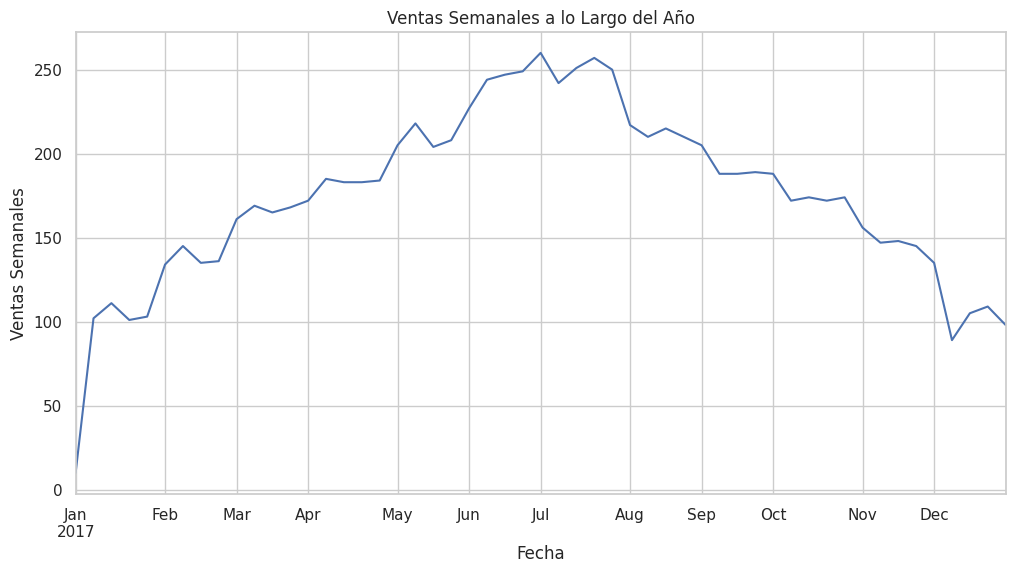

In [ ]:
plt.figure(figsize=(12, 6))
ventas_por_semana.plot(kind='line')
plt.title('Ventas Semanales a lo Largo del Año')
plt.xlabel('Fecha')
plt.ylabel('Ventas Semanales')
plt.grid(True)
plt.show()

### Gráfico de la Evolución Diaria de las Ventas

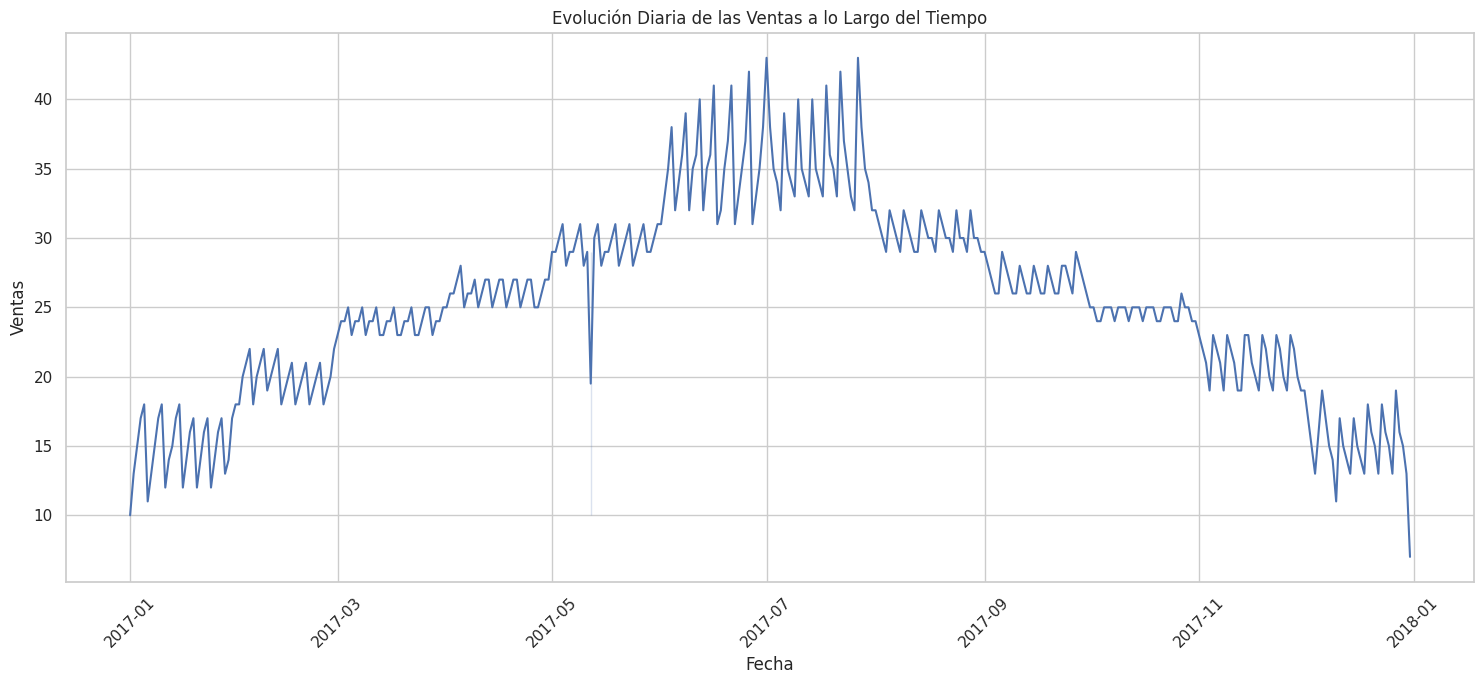

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(x=df.index, y='Sales', data=df)
plt.title('Evolución Diaria de las Ventas a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se nota en este gráfico y el inmediatamente anterior que las ventas con mayor cantidad se dieron a mediados del año (entre mayo y septiembre).

In [ ]:
#Tendencia central Ventas
mean_sales = df["Sales"].mean() #Media
median_sales = df["Sales"].median() #Mediana
mode_sales = df["Sales"].mode()[0] #Moda

print(mean_sales, median_sales, mode_sales)

25.323287671232876 25.0 25


In [ ]:
#Tendencia central Temperatura
mean_temp = df["Temperature"].mean() #Media
median_temp = df["Temperature"].median() #Mediana
mode_temp = df["Temperature"].mode()[0] #Moda

print(mean_temp, median_temp, mode_temp)

15.336529680365295 16.0 13.277777777777779


In [ ]:
#Tendencia central Precipitaciones
mean_precipitacion = df["Rainfall"].mean() #Media
median_precipitacion = df["Rainfall"].median() #Mediana
mode_precipitacion = df["Rainfall"].mode()[0] #Moda

print(mean_precipitacion, median_precipitacion, mode_precipitacion)

0.8266027397260275 0.74 0.74


In [ ]:
#Tendencia central Volantes
mean_volantes = df["Flyers"].mean() #Media
median_volantes  = df["Flyers"].median() #Mediana
mode_volantes  = df["Flyers"].mode()[0] #Moda

print(mean_volantes , median_volantes , mode_volantes)

40.28493150684932 39.0 28


#Medidad de posición (Cuartiles)

In [ ]:
#Permite ver cómo se distribuyen las ventas por cuartiles.

In [ ]:
#Ventas
df["Sales"].quantile([0.25, 0.5, 0.75])

,Sales
0.25,20.0
0.50,25.0
0.75,30.0


In [ ]:
#Temperatura
df["Temperature"].quantile([0.25, 0.5, 0.75])

,Temperature
0.25,9.277778
0.50,16.000000
0.75,21.833333


In [ ]:
#Precipitaciones
# Los cuartiles dividen los datos en cuatro partes iguales, cada una representando el 25% de las observaciones.
# Son útiles para entender la distribución y la dispersión de los datos.
#
# Interpretación:
# - 25% (Q1): El 25% de los días tuvieron precipitaciones iguales o inferiores a este valor.
# - 50% (Mediana/Q2): El 50% de los días tuvieron precipitaciones iguales o inferiores a este valor.
# - 75% (Q3): El 75% de los días tuvieron precipitaciones iguales o inferiores a este valor.

rainfall_quantiles = df["Rainfall"].quantile([0.25, 0.5, 0.75])
print("Cuartiles de Precipitaciones:")
print(rainfall_quantiles)

,Rainfall
0.25,0.65
0.50,0.74
0.75,0.91


In [ ]:
#Volantes
df["Flyers"].quantile([0.25, 0.5, 0.75])

,Flyers
0.25,31.0
0.50,39.0
0.75,49.0


#Medidas de dispersión

In [ ]:
#Desviación estándar alta → ventas muy variables.
#Rango amplio → diferencias grandes entre días buenos y malos.

In [ ]:
#Ventas
std_sales = df["Sales"].std()
var_sales = df["Sales"].var()
range_sales = df["Sales"].max() - df["Sales"].min()

print(std_sales, var_sales, range_sales)

6.893589165239386 47.52157157910585 36


In [ ]:
#Temperatura
std_Temperature = df["Temperature"].std()
var_Temperature = df["Temperature"].var()
range_Temperature = df["Temperature"].max() - df["Temperature"].min()

print(std_Temperature, var_Temperature, range_Temperature)

9.996008815422309 99.9201922380005 56.55555555555556


In [ ]:
#Precipitaciones
std_precipitacion = df["Rainfall"].std()
var_precipitacion = df["Rainfall"].var()
range_precipitacion = df["Rainfall"].max() - df["Rainfall"].min()

print(std_precipitacion, var_precipitacion, range_precipitacion)

0.2731711786583939 0.07462249284961615 2.0300000000000002


In [ ]:
#Volantes
std_volantes = df["Flyers"].std()
var_volantes = df["Flyers"].var()
range_volantes = df["Flyers"].max() - df["Flyers"].min()

print(std_volantes, var_volantes, range_volantes)

13.178650642470377 173.67683275628485 71


##Identificando valores atípicos

In [ ]:
for col in df.select_dtypes(include=np.number).columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5*IQR
    limite_sup = Q3 + 1.5*IQR

    outliers = df[(df[col] < limite_inf) |
                  (df[col] > limite_sup)]

    print(col, len(outliers))

Temperature 8
Rainfall 28
Flyers 2
Price 62
Sales 0


Se nota entonces que la columna con mayor numero de outliers es la de Price con 62, seguido dela columna Rainfall con 28

#Forma de la distribución o medidas de forma

In [ ]:
#Ventas
skewnessV = df["Sales"].skew()
kurtosisV = df["Sales"].kurt()

print(f"Asimetría (Skewness) de Ventas: {skewnessV:.4f}")
print(f"Curtosis (Kurtosis) de Ventas: {kurtosisV:.4f}")

# Interpretación de Asimetría (Skewness) y Curtosis (Kurtosis) para las 'Sales':
# Skewness (0.02): El valor muy cercano a cero indica una distribución casi simétrica,
# sin un sesgo significativo hacia ventas altas o bajas.
#
# Kurtosis (-0.25): El valor negativo (curtosis platicúrtica) indica colas más ligeras
# y un pico más plano que una distribución normal. Sugiere menos valores extremos
# y una mayor dispersión alrededor de la media.

Asimetría (Skewness) de Ventas: 0.0237
Curtosis (Kurtosis) de Ventas: -0.2503


la asimetría se acerca a cero, lo que indica una distribucion simétrica. El valor positivo indica una cola más larga hacia la derecha. Su valor negativo en la curotsis indica colas más ligeras y un pico plano.

In [ ]:
#Temperatura
skewnessT = df["Temperature"].skew()
kurtosisT = df["Temperature"].kurt()

print(f"Asimetría (Skewness) de Temperatura: {skewnessT:.4f}")
print(f"Curtosis (Kurtosis) de Temperatura: {kurtosisT:.4f}")

# Interpretación de Asimetría (Skewness) y Curtosis (Kurtosis) para la 'Temperatura':
# Skewness (-0.48): El valor negativo indica una distribución sesgada hacia la izquierda,
# con una cola más larga hacia las temperaturas bajas y una mayor concentración de temperaturas altas.
#
# Kurtosis (0.83): El valor positivo (curtosis de exceso) indica una distribución leptocúrtica,
# con un pico más pronunciado y colas más pesadas que una distribución normal.
# Esto sugiere más valores extremos y una mayor concentración alrededor de la media.

Asimetría (Skewness) de Temperatura: -0.4801
Curtosis (Kurtosis) de Temperatura: 0.8289


Se cuenta con una cola que es mas larga hacia izquierda. Este valor positivo indica colas mas pesdas y picos mas pronunciados

In [ ]:
#Precipitacion
skewnessR = df["Rainfall"].skew()
kurtosisR = df["Rainfall"].kurt()

print(f"Asimetría (Skewness) de Precipitaciones: {skewnessR:.4f}")
print(f"Curtosis (Kurtosis) de Precipitaciones: {kurtosisR:.4f}")

# Interpretación de Asimetría (Skewness) y Curtosis (Kurtosis) para la 'Rainfall':
# Skewness (1.86): El valor positivo indica una distribución fuertemente sesgada hacia la derecha,
# con una cola larga hacia valores de precipitación más altos y una concentración en valores bajos.
#
# Kurtosis (5.24): El valor positivo (curtosis de exceso) indica una distribución leptocúrtica,
# con un pico muy pronunciado y colas pesadas. Esto sugiere una alta concentración alrededor de la media
# y una mayor probabilidad de eventos de precipitación extremos.

1.8554090769287244 5.244273817109876


In [ ]:
#Volantes
skewnessF = df["Flyers"].skew()
kurtosisF = df["Flyers"].kurt()

print(f"Asimetría (Skewness) de Volantes: {skewnessF:.4f}")
print(f"Curtosis (Kurtosis) de Volantes: {kurtosisF:.4f}")

# Interpretación de Asimetría (Skewness) y Curtosis (Kurtosis) para 'Flyers':
# Skewness (0.31): El valor positivo y cercano a cero indica una distribución ligeramente sesgada hacia la derecha,
# con una cola un poco más larga hacia un mayor número de volantes.
#
# Kurtosis (-0.15): El valor negativo (curtosis platicúrtica) indica colas ligeramente más ligeras
# y un pico más plano que una distribución normal. Sugiere menos valores extremos
# y una mayor dispersión alrededor de la media.

0.30604723553965185 -0.14720246325479325


# Histogramas

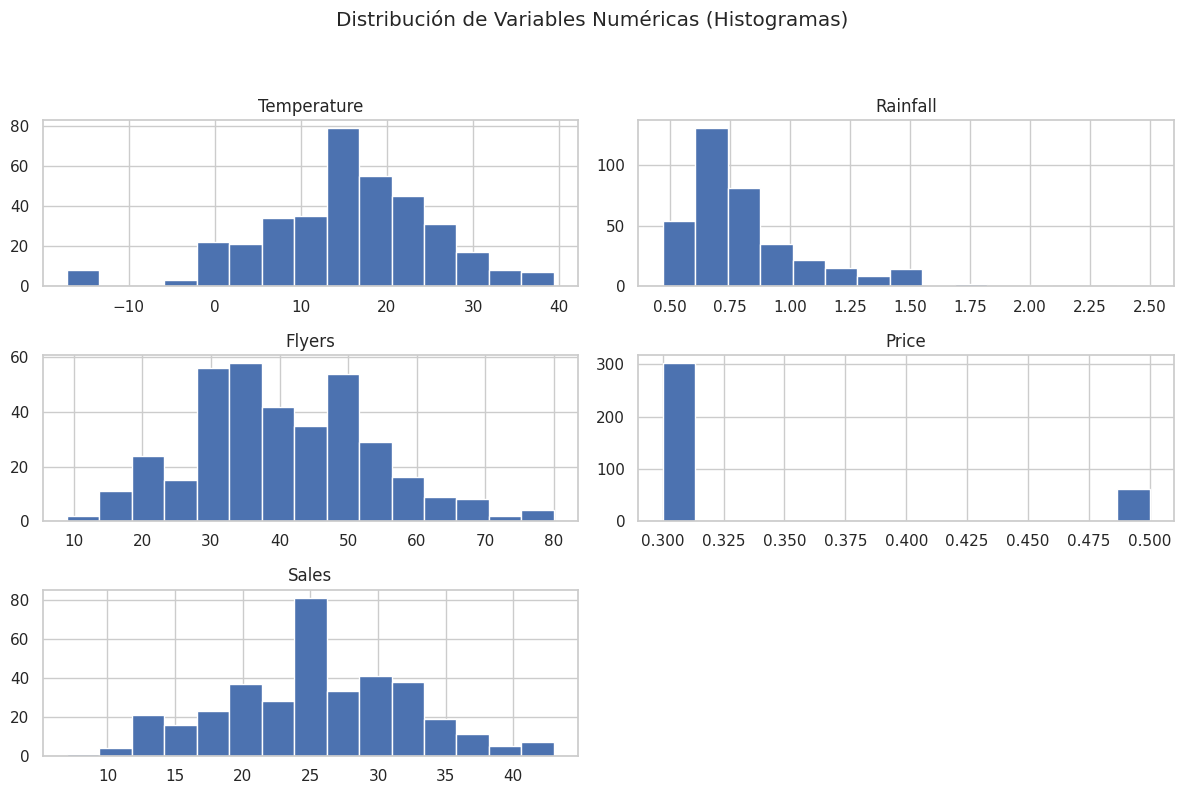

In [ ]:
# Este código genera histogramas para todas las columnas numéricas en el DataFrame.
# Los histogramas son útiles para visualizar la distribución de los datos de cada variable.
#
# Interpretación de los Histogramas:
# - Forma (Shape): Observa si la distribución es simétrica, sesgada a la izquierda (cola más larga a la izquierda)
#   o sesgada a la derecha (cola más larga a la derecha). Esto se relaciona con el 'Skewness' calculado previamente.
#   Por ejemplo, una cola larga a la derecha sugiere una asimetría positiva.
# - Pico (Peak): Observa si la distribución tiene uno o varios picos.
# - Colas (Tails): Observa si las colas son "pesadas" (muchos valores extremos) o "ligeras" (pocos valores extremos).
#   Esto se relaciona con el 'Kurtosis' calculado: colas pesadas y un pico pronunciado indican leptocurtosis (Kurtosis > 0),
#   mientras que colas ligeras y un pico plano indican platicurtosis (Kurtosis < 0).
#
# Parámetros utilizados:
# - figsize=(12, 8): Define el tamaño total de la figura para los histogramas.
# - bins=15: Establece el número de 'bins' (barras) para cada histograma. Un mayor número de bins
#   muestra más detalle, pero puede hacer la gráfica ruidosa; un menor número puede ocultar detalles.

df.hist(
    figsize=(12,8),
    bins=15
)
plt.suptitle('Distribución de Variables Numéricas (Histogramas)', y=1.02) # Título general para toda la figura
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar layout para evitar que el título se superponga
plt.show()

#Boxplots

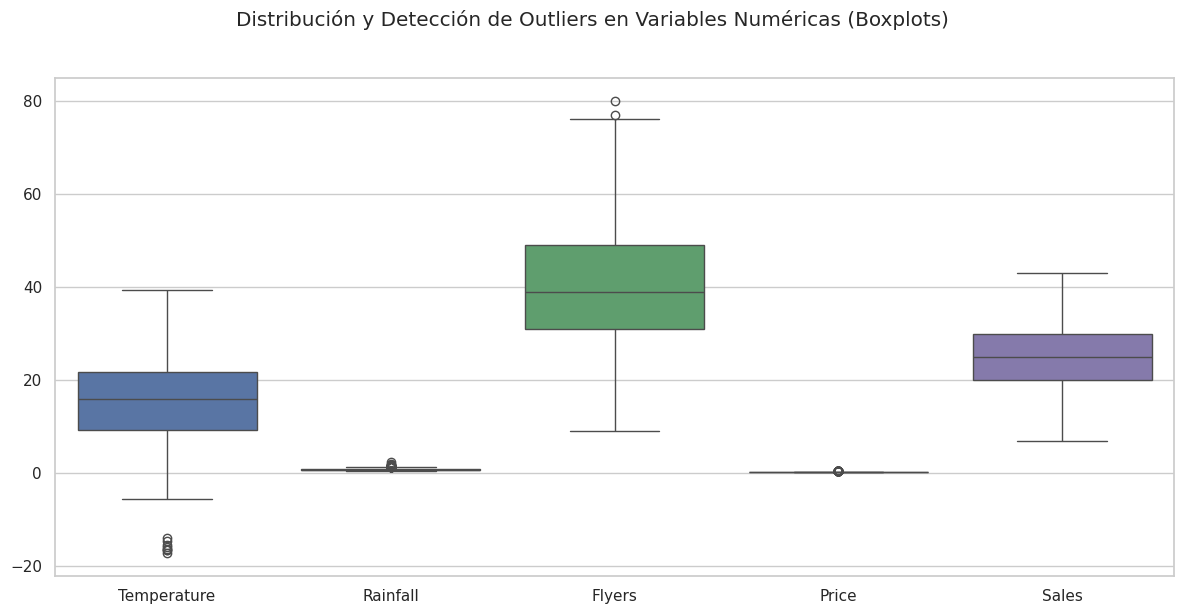

In [ ]:
# Este código genera gráficos de caja (boxplots) para todas las columnas numéricas en el DataFrame.
# Los boxplots son herramientas excelentes para visualizar la distribución de los datos, la tendencia central,
# la dispersión y, muy importante, la presencia de valores atípicos (outliers).
#
# Interpretación de un Boxplot:
# - La línea central dentro de la caja representa la MEDIANA (Q2), que es el valor que divide los datos
#   en dos mitades iguales. Es el 50% de los datos.
# - Los límites de la CAJA representan el PRIMER CUARTIL (Q1) y el TERCER CUARTIL (Q3).
#   Esto significa que el 50% central de los datos se encuentra dentro de la caja.
# - La longitud de la caja es el RANGO INTERCUARTÍLICO (IQR = Q3 - Q1).
# - Los 'BIGOTES' (whiskers) se extienden desde la caja hasta el último dato que no se considera un outlier.
#   Generalmente, se extienden hasta 1.5 veces el IQR desde Q1 y Q3.
# - Los PUNTOS individuales fuera de los bigotes son los VALORES ATÍPICOS (OUTLIERS).
#   Estos son valores que son significativamente diferentes del resto de los datos y merecen una investigación.

plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.suptitle('Distribución y Detección de Outliers en Variables Numéricas (Boxplots)', y=1.02)
plt.tight_layout()
plt.show()

### Cálculo de la Matriz de Correlación

In [ ]:
# Este código calcula la matriz de correlación para todas las columnas numéricas en el DataFrame.
# La matriz de correlación nos permite entender la relación lineal entre pares de variables.
#
# Interpretación de la Matriz de Correlación:
# - Los valores varían de -1 a 1.
# - Un valor cercano a 1 indica una fuerte correlación positiva: cuando una variable aumenta, la otra también.
# - Un valor cercano a -1 indica una fuerte correlación negativa: cuando una variable aumenta, la otra disminuye.
# - Un valor cercano a 0 indica poca o ninguna correlación lineal entre las variables.
# - La diagonal principal siempre es 1, ya que una variable siempre está perfectamente correlacionada consigo misma.

print("Matriz de Correlación de Variables Numéricas:")
corr_matrix = df.corr(numeric_only=True)
display(corr_matrix)

Matriz de Correlación de Variables Numéricas:


,Temperature,Rainfall,Flyers,Price,Sales
Temperature,1.000000,-0.811049,0.711414,0.450165,0.886627
Rainfall,-0.811049,1.000000,-0.747389,-0.383775,-0.909214
Flyers,0.711414,-0.747389,1.000000,0.405437,0.805183
Price,0.450165,-0.383775,0.405437,1.000000,0.512908
Sales,0.886627,-0.909214,0.805183,0.512908,1.000000


#Correlaciones

#HeatMap

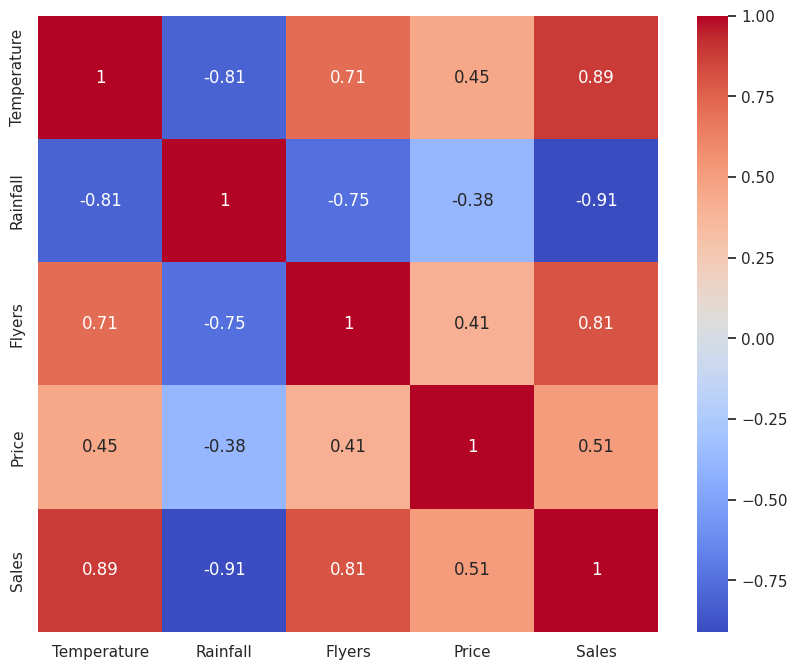

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

#Gráficos de dispersión

In [ ]:
# Los códigos que siguen a continuación, generan gráficos de dispersión para visualizar la relación entre 'Sales'
# y cada una de las otras columnas numéricas en el DataFrame.
# Los gráficos de dispersión son fundamentales para identificar visualmente la correlación,
# tendencias y posibles patrones entre dos variables.
#
# Interpretación de los Gráficos de Dispersión:
# - Si los puntos tienden a subir de izquierda a derecha, indica una correlación positiva:
#   a medida que la variable X aumenta, 'Sales' también tiende a aumentar (ej. 'Sales' vs 'Temperature').
# - Si los puntos tienden a bajar de izquierda a derecha, indica una correlación negativa:
#   a medida que la variable X aumenta, 'Sales' tiende a disminuir (ej. 'Sales' vs 'Rainfall').
# - Si los puntos están dispersos sin un patrón claro, sugiere poca o ninguna correlación lineal.
# - La dispersión de los puntos también puede indicar la fuerza de la relación: cuanto más agrupados
#   estén los puntos alrededor de una línea, más fuerte es la correlación.
# - Los puntos alejados del patrón principal pueden ser valores atípicos (outliers) que merecen investigación.

### Gráfico de dispersión: Sales vs Temperature

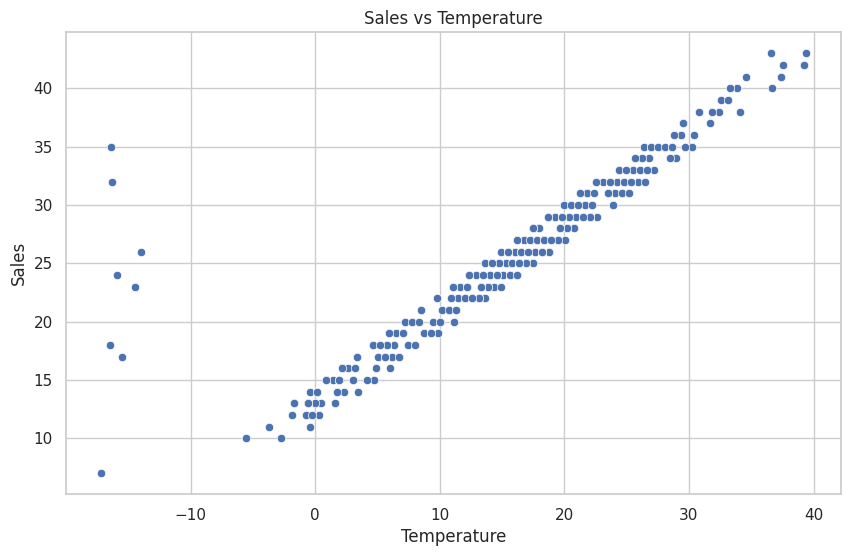

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Sales', data=df)
plt.title('Sales vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.show()

### Gráfico de dispersión: Sales vs Rainfall

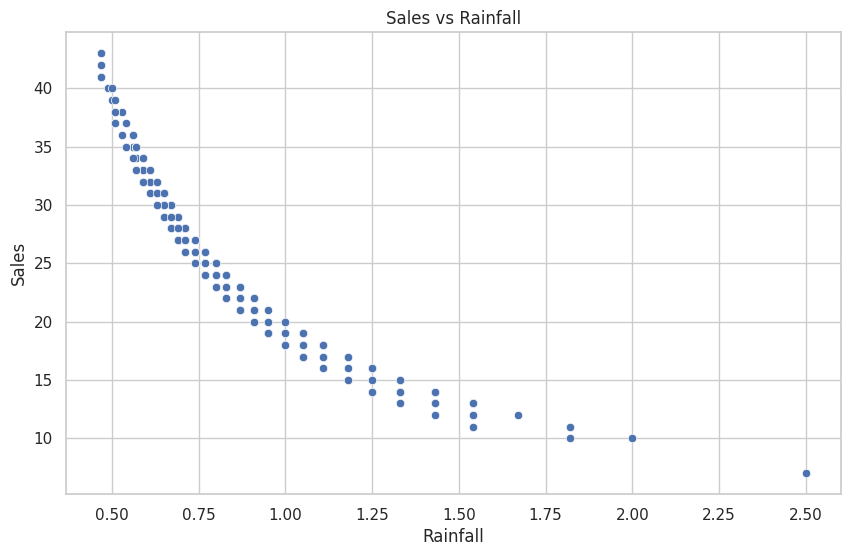

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rainfall', y='Sales', data=df)
plt.title('Sales vs Rainfall')
plt.xlabel('Rainfall')
plt.ylabel('Sales')
plt.show()

### Gráfico de dispersión: Sales vs Flyers

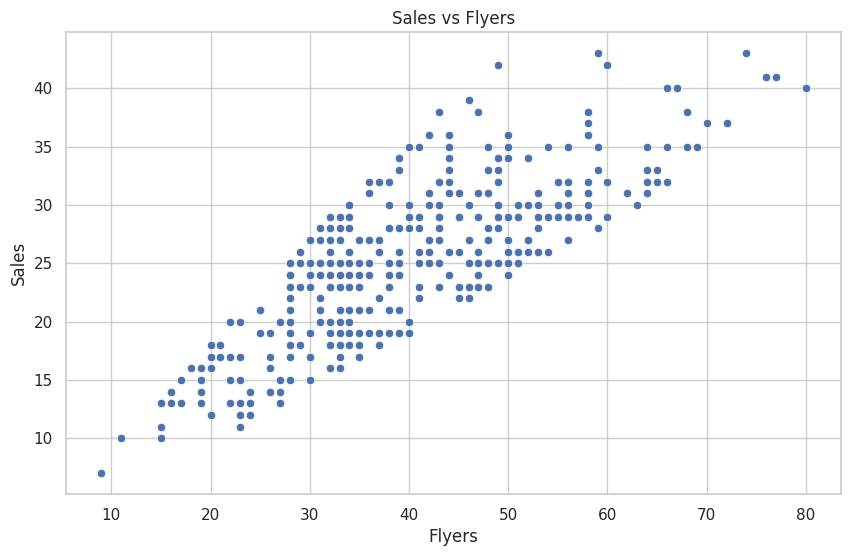

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Flyers', y='Sales', data=df)
plt.title('Sales vs Flyers')
plt.xlabel('Flyers')
plt.ylabel('Sales')
plt.show()

### Modelo de Regresión Lineal para Predecir 'Sales'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definir las características (X) y la variable objetivo (y)
# Excluiremos 'Día' ya que es categórica y 'Price' si siempre es 0.3 (o se asume constante).
X = df[['Temperature', 'Rainfall', 'Flyers']]
y = df['Sales']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Dimensiones de X_train: {X_train.shape}')
print(f'Dimensiones de X_test: {X_test.shape}')
print(f'Dimensiones de y_train: {y_train.shape}')
print(f'Dimensiones de y_test: {y_test.shape}')

Dimensiones de X_train: (292, 3)
Dimensiones de X_test: (73, 3)
Dimensiones de y_train: (292,)
Dimensiones de y_test: (73,)


#### Entrenamiento del Modelo

Vamos a construir un modelo de regresión lineal para predecir 'Sales'. Esto incluirá la preparación de datos, el entrenamiento del modelo, las predicciones y la evaluación del rendimiento.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(f'Coeficientes del modelo: {model.coef_}')
print(f'Intersección del modelo: {model.intercept_}')

Coeficientes del modelo: [  0.27749269 -11.76562471   0.09236154]
Intersección del modelo: 27.04019644606178


#### Predicciones y Evaluación del Modelo

In [ ]:
# Este código realiza predicciones con el modelo de regresión lineal entrenado
# y luego evalúa su rendimiento utilizando métricas clave.

y_pred = model.predict(X_test)

# Error Absoluto Medio (MAE): Mide la magnitud promedio de los errores.
# Ignora la dirección de los errores. Es fácil de interpretar.
mae = mean_absolute_error(y_test, y_pred)

# Error Cuadrático Medio (MSE): Mide la magnitud promedio de los errores al cuadrado.
# Penaliza más fuertemente los errores grandes.
mse = mean_squared_error(y_test, y_pred)

# Raíz del Error Cuadrático Medio (RMSE): Es la raíz cuadrada del MSE.
# Está en la misma unidad que la variable objetivo, lo que facilita su interpretación.
rmse = np.sqrt(mse)

# Coeficiente de Determinación (R²): Mide la proporción de la varianza en la variable
# dependiente que es predecible a partir de las variables independientes. Rango de 0 a 1 (o puede ser negativo).
# Un valor cercano a 1 indica que el modelo explica una gran parte de la variabilidad.
r2 = r2_score(y_test, y_pred)

print(f'Error Absoluto Medio (MAE): {mae:.2f}')
print(f'Error Cuadrático Medio (MSE): {mse:.2f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}')
print(f'Coeficiente de Determinación (R²): {r2:.2f}')

Error Absoluto Medio (MAE): 1.52
Error Cuadrático Medio (MSE): 5.46
Raíz del Error Cuadrático Medio (RMSE): 2.34
Coeficiente de Determinación (R²): 0.89


#### Visualización de Predicciones vs Valores Reales

Este código genera un gráfico de dispersión para visualizar la relación entre las ventas reales y las ventas que nuestro modelo de regresión lineal ha predicho.

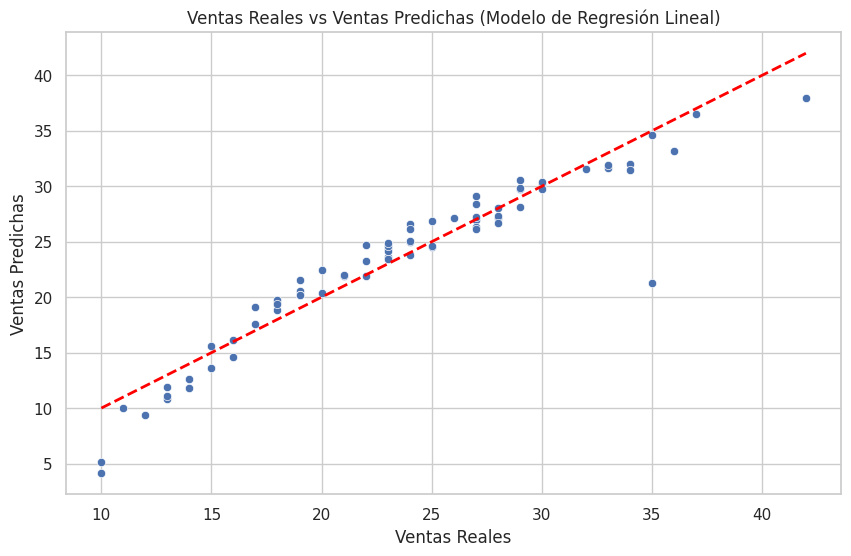

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Ventas Reales')
plt.ylabel('Ventas Predichas')
plt.title('Ventas Reales vs Ventas Predichas (Modelo de Regresión Lineal)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.grid(True)
plt.show()

Interpretación: Cuanto más cerca estén los puntos azules de esta línea roja, mejor es la predicción del modelo. Si todos los puntos estuvieran sobre la línea roja, el modelo sería perfecto

### Gráfico de Barras: Promedio de Ventas por Día de la Semana

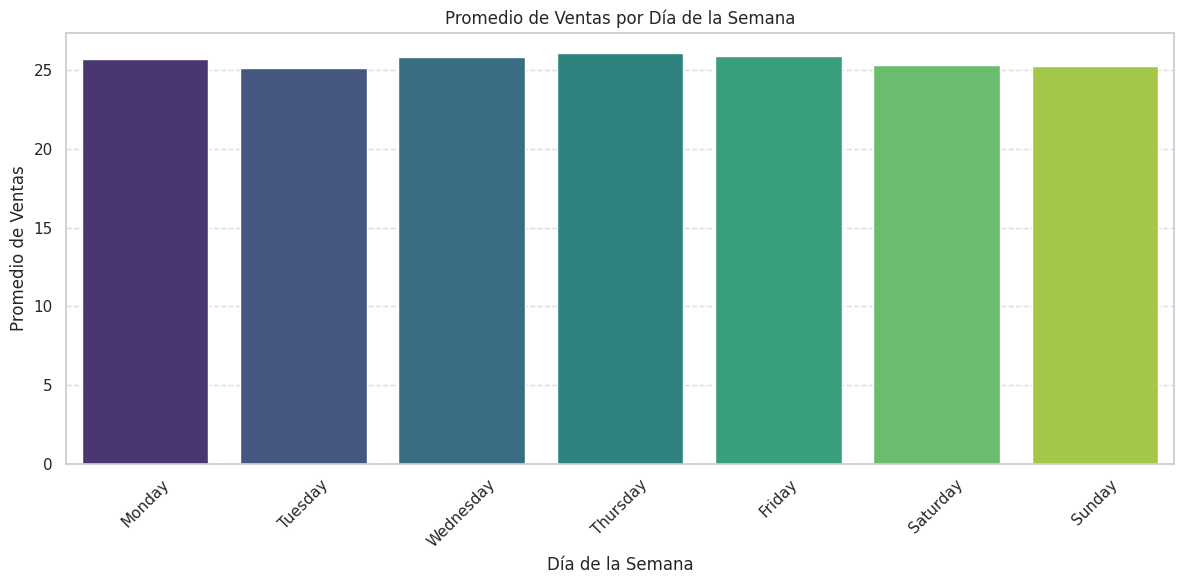

In [ ]:
avg_sales_by_day = df.groupby('Día')['Sales'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_sales_by_day.index, y=avg_sales_by_day.values, palette='viridis', hue=avg_sales_by_day.index, legend=False)
plt.title('Promedio de Ventas por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Promedio de Ventas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()